# Atelier Scikit-learn

Une entreprise possède plusieurs bâtiments équipés de capteurs IoT. Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression, la consommation énergétique, le bâtiment, la date et l'heure de la mesure.  

Chaque mesure possède également un état (OK, ALERTE et ERREUR). L'objectif de l'atelier est de construire un modèle capable de prédire automatiquement l'état d'un capteur à partir de ses mesures. 

L'atelier suivra le workflow classique du Machine Learning : Dataset → Chargement → Exploration → Nettoyage → X / y → Train / Test → Prétraitement → Modèle → fit()→ predict()→ Évaluation → Sauvegarde → Chargement → Réutilisation 

## Partie 0 – mise en place de l’environnement 

**Objectif** : préparer l'environnement de travail en important les librairies nécessaires (manipulation de données et visualisation), avant de charger et explorer le dataset.

In [ ]:
#Installer et importer seaborn, matplotlib et pandas si pas encore
#%pip install pandas seaborn matplotlib scikit-learn

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pour un affichage plus agréable des graphiques dans le notebook
%matplotlib inline

### Importer mesures_capteurs.csv dans le dataframe df et Explorer le dataframe df 

In [2]:
df = pd.read_csv("../data/mesures_capteurs.csv")

**Explication** : `pd.read_csv()` lit le fichier CSV situé dans `data/` et le charge dans un DataFrame Pandas nommé `df`. Le chemin `../data/mesures_capteurs.csv` remonte d'un niveau (depuis `notebooks/`) puis entre dans `data/`, ce qui suppose que le notebook est exécuté depuis le dossier `notebooks/`.

**Résultat** : le dataset est chargé en mémoire sous forme de tableau, prêt à être exploré.

In [3]:
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


**Explication** : `df.head()` affiche par défaut les 5 premières lignes du DataFrame, pour avoir un premier aperçu visuel des données.

**Résultat** : on voit les colonnes `id_mesure, date_heure, id_capteur, batiment, temperature, humidite, pression, consommation, etat`, avec des valeurs cohérentes (ex. température autour de 20-30°C, état "OK").

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


**Explication** : `df.info()` affiche pour chaque colonne son type (`object` pour du texte, `float64` pour des nombres décimaux) ainsi que le nombre de valeurs non nulles. Cela permet de repérer immédiatement les valeurs manquantes par colonne.

**Résultat** : le dataset contient 605 lignes. Les colonnes `temperature`, `humidite`, `pression`, `consommation` et `etat` contiennent chacune quelques valeurs manquantes (moins de 600 valeurs non nulles sur 605).

In [5]:
df.describe()

,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


In [6]:
df.shape

(605, 9)

**Explication** : `df.shape` retourne un tuple (nombre de lignes, nombre de colonnes).

**Résultat** : le dataset contient **605 lignes** et **9 colonnes**.

In [7]:
df.columns

Index(['id_mesure', 'date_heure', 'id_capteur', 'batiment', 'temperature',
       'humidite', 'pression', 'consommation', 'etat'],
      dtype='str')

**Explication** : `df.columns` liste les noms de toutes les colonnes du DataFrame.

**Résultat** : `id_mesure, date_heure, id_capteur, batiment, temperature, humidite, pression, consommation, etat`.

In [8]:
df["etat"].value_counts(dropna=False)

etat
OK        567
ALERTE     29
ERREUR      5
NaN         4
Name: count, dtype: int64

**Explication** : `value_counts()` compte le nombre d'occurrences de chaque valeur unique de la colonne `etat` (la cible qu'on cherche à prédire). Le paramètre `dropna=False` inclut aussi le comptage des valeurs manquantes (`NaN`).

**Résultat** : la colonne `etat` contient 567 mesures "OK", 29 "ALERTE", 5 "ERREUR", et 4 valeurs manquantes.

## Partie 1 – Gestion des doublons 

**Objectif** : vérifier si le dataset contient des lignes strictement identiques (doublons), qui pourraient fausser l'entraînement du modèle en sur-représentant artificiellement certaines observations, puis les supprimer le cas échéant.

### 1) vérifier l’existence de doublons dans df 

In [9]:
print("Nombre de doublons :", df.duplicated().sum())
df[df.duplicated()]

Nombre de doublons : 5


,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
183,M0599,2026-01-29 22:00:00,C011,B004,22.02,68.09,1005.90,227.81,OK
231,M0026,2026-01-06 01:00:00,C002,B001,22.87,77.99,1010.15,213.19,OK
355,M0147,2026-01-11 02:00:00,C003,B001,26.14,84.97,1003.59,142.31,OK
538,M0456,2026-01-23 23:00:00,C012,B004,20.68,72.69,1022.77,309.01,OK
539,M0302,2026-01-17 13:00:00,C002,B001,22.05,58.26,1007.30,140.42,OK


**Explication** : `df.duplicated()` retourne une série de booléens (`True` si la ligne est identique à une ligne déjà rencontrée précédemment, `False` sinon). `.sum()` additionne les `True` (comptés comme 1), donnant ainsi le nombre total de doublons. `df[df.duplicated()]` permet d'afficher ces lignes dupliquées.

**Résultat** : le dataset contient **5 doublons**.

### 2) le cas échéant, supprimer les doublons puis vérifier la suppression  

In [10]:
print("Shape avant suppression :", df.shape)

df = df.drop_duplicates()

print("Shape après suppression :", df.shape)
print("Doublons restants :", df.duplicated().sum())

Shape avant suppression : (605, 9)
Shape après suppression : (600, 9)
Doublons restants : 0


**Explication** : `df.drop_duplicates()` supprime les lignes dupliquées en ne conservant que la première occurrence de chaque ligne identique. On revérifie ensuite avec `duplicated().sum()` pour confirmer qu'il n'en reste plus.

**Résultat** : le dataset passe de **605 à 600 lignes** après suppression des 5 doublons. La vérification confirme **0 doublon restant**.

## Partie 2 – Sélection de y (cible) et X (caractéristiques)

**Objectif** : séparer le dataset en deux ensembles — `X`, les variables explicatives (caractéristiques) qui serviront à faire la prédiction, et `y`, la variable cible (ce qu'on cherche à prédire).

### 1) Définir "etat" comme la cible ou valeur à prédire et "temperature", "humidite", "pression" et "consommation" comme caractéristiques ou variables explicatives 

In [12]:
X = df[["temperature", "humidite", "pression", "consommation"]]
y = df["etat"]

### 2) Afficher les cinq premières lignes de X et de y

In [13]:
print(X.head())
print()
print(y.head())

   temperature  humidite  pression  consommation
0        25.46     58.06   1008.95        287.28
1        24.00     79.73    993.39        116.20
2        25.82     54.47   1010.32        288.50
3        28.23     69.39   1019.62        136.65
4        20.58     53.80   1016.58        182.62

0    OK
1    OK
2    OK
3    OK
4    OK
Name: etat, dtype: str


**Explication** : `df[[...]]` avec une liste de colonnes sélectionne plusieurs colonnes et retourne un DataFrame — ce sont les 4 caractéristiques (`temperature`, `humidite`, `pression`, `consommation`) qui vont permettre au modèle de faire ses prédictions. `df["etat"]` avec une seule colonne entre crochets simples retourne une Series, c'est la cible que le modèle doit apprendre à prédire.

**Résultat** : `X` contient 4 colonnes numériques (les mesures des capteurs), `y` contient la colonne `etat` avec des valeurs comme "OK".

### 3) Quel est le type du problème de machine learning ?  

Il s'agit d'un problème d'**apprentissage supervisé de classification**, et plus précisément une **classification multi-classes** (3 classes possibles : `OK`, `ALERTE`, `ERREUR`). On parle d'apprentissage supervisé car on dispose d'exemples déjà étiquetés (la colonne `etat` est connue dans les données d'entraînement), et de classification car la cible à prédire est une catégorie discrète (et non une valeur numérique continue, ce qui serait de la régression).

## Partie 3 – Découpage Train/Test

**Objectif** : diviser les données en un ensemble d'entraînement (train) et un ensemble de test (test), afin de pouvoir évaluer le modèle sur des données qu'il n'a jamais vues pendant l'entraînement.

**Prérequis** : `y` contient encore 4 valeurs manquantes (`etat` = NaN). Une ligne sans cible connue ne peut pas être imputée (contrairement à une variable explicative) ni utilisée pour l'entraînement ou le test, on la supprime donc avant le découpage.

In [16]:
print("Lignes avant suppression des etat manquants :", df.shape)

df = df.dropna(subset=["etat"])

print("Lignes après suppression des etat manquants :", df.shape)

# On redéfinit X et y sur le df nettoyé
X = df[["temperature", "humidite", "pression", "consommation"]]
y = df["etat"]

Lignes avant suppression des etat manquants : (596, 9)
Lignes après suppression des etat manquants : (596, 9)


**Explication** : `df.dropna(subset=["etat"])` supprime uniquement les lignes où la colonne `etat` est manquante (les autres valeurs manquantes, dans X, seront traitées séparément en Partie 4). On redéfinit ensuite X et y à partir de ce dataframe nettoyé.
**subset** : supprime une ligne seulement si la colonne etat est NaN, ignore les NaN dans les autres colonnes (temperature, humidite, etc.)". C'est important ici car on ne veut pas encore toucher aux valeurs manquantes de X, on veut uniquement se débarrasser des lignes où la cible y est inconnue.

**Résultat** : le dataset passe de 600 à **596 lignes** (4 lignes avec `etat` manquant supprimées).

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (476, 4)
X_test : (120, 4)
y_train : (476,)
y_test : (120,)


In [20]:
print("Répartition dans y (données complètes) :")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nRépartition dans y_train :")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nRépartition dans y_test :")
print((y_test.value_counts(normalize=True) * 100).round(2))

Répartition dans y (données complètes) :
etat
OK        94.30
ALERTE     4.87
ERREUR     0.84
Name: proportion, dtype: float64

Répartition dans y_train :
etat
OK        94.33
ALERTE     4.83
ERREUR     0.84
Name: proportion, dtype: float64

Répartition dans y_test :
etat
OK        94.17
ALERTE     5.00
ERREUR     0.83
Name: proportion, dtype: float64


**Explication** :

Le split est réalisé sur `X` et `y` (596 lignes restantes après suppression des `etat` manquants), avec :

- **`test_size=0.2`** : réserve 20 % des lignes pour l'ensemble de test, et donc 80 % pour l'ensemble d'entraînement.
- **`random_state=42`** : fixe la graine du générateur aléatoire utilisé pour choisir les lignes. Sans ce paramètre, le découpage serait différent à chaque exécution ; avec `random_state=42`, il est identique à chaque fois, ce qui rend le résultat reproductible.
- **`stratify=y`** : impose que la proportion de chaque classe (`OK`, `ALERTE`, `ERREUR`) soit respectée à l'identique dans `y_train` et dans `y_test`, plutôt que de tirer les lignes au hasard. C'est essentiel ici car les classes sont très déséquilibrées (94 % de `OK`) — sans stratification, l'ensemble de test pourrait par exemple ne contenir aucune ligne `ERREUR`.

La vérification des proportions est faite avec la fonction `value_counts(normalize=True)`, qui calcule la proportion de chaque classe (nombre d'occurrences ÷ total des lignes) au lieu d'un simple compte brut. On multiplie par 100 pour obtenir un pourcentage.

**Résultat** :

`X_train` contient 476 lignes, `X_test` 120 lignes (soit bien 80 % / 20 % de 596 lignes).

- Données complètes : OK 94.30 % / ALERTE 4.87 % / ERREUR 0.84 %
- Train : OK 94.33 % / ALERTE 4.83 % / ERREUR 0.84 %
- Test : OK 94.17 % / ALERTE 5.00 % / ERREUR 0.83 %

Les écarts entre les trois répartitions sont minimes (moins de 0.2 point de pourcentage), ce qui confirme que le train et le test sont bien représentatifs de la distribution originale des classes.

## Partie 4 – Gestion des valeurs manquantes 

**Objectif** : détecter les valeurs manquantes restantes dans les variables explicatives (X) et les remplacer par une valeur statistique cohérente, afin que le modèle puisse s'entraîner (la plupart des algorithmes de scikit-learn n'acceptent pas de NaN en entrée).

### 1) Vérifier l’existence de valeurs manquantes

In [21]:
print("Valeurs manquantes dans X_train :")
print(X_train.isna().sum())

print("\nValeurs manquantes dans X_test :")
print(X_test.isna().sum())

Valeurs manquantes dans X_train :
temperature     5
humidite        4
pression        5
consommation    3
dtype: int64

Valeurs manquantes dans X_test :
temperature     1
humidite        1
pression        0
consommation    2
dtype: int64


**Explication** : `isna()` retourne `True` pour chaque cellule manquante, `sum()` compte le nombre de `True` par colonne.

**Résultat** : X_train contient des valeurs manquantes dans `temperature` (5), `humidite` (4), `pression` (5) et `consommation` (3). X_test en contient aussi (`temperature` : 1, `humidite` : 1, `consommation` : 2, `pression` : 0).

###  2) Sélectionner SimpleImputer avec la médiane

In [22]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

**Explication** : `SimpleImputer` est un outil de scikit-learn qui remplace les valeurs manquantes par une statistique calculée sur les données. `strategy="median"` indique qu'on utilisera la **médiane** de chaque colonne pour combler ses valeurs manquantes.

###  3) Qu’est ce qui justifie le choix de la médiane ?

La médiane est plus **robuste aux valeurs extrêmes (outliers)** que la moyenne. Une valeur aberrante très élevée ou très basse peut fortement déformer la moyenne, alors que la médiane (la valeur du milieu une fois les données triées) n'est pas affectée par l'ampleur des valeurs extrêmes, seulement par leur position. Pour des mesures de capteurs IoT, où des erreurs de mesure ponctuelles (température ou humidité incohérentes) sont plausibles, la médiane donne une estimation plus fiable de la "valeur typique" que la moyenne.

###  4) Trouver les paramètres (médianes) de l’imputeur sur X_train

In [24]:
# Apprentissage des médianes sur X_train uniquement
imputer.fit(X_train)

print("Médianes apprises :")
print(dict(zip(X_train.columns, imputer.statistics_)))

Médianes apprises :
{'temperature': np.float64(24.9), 'humidite': np.float64(65.38), 'pression': np.float64(1012.3), 'consommation': np.float64(206.59)}


**Explication** : `imputer.fit(X_train)` calcule et mémorise la médiane de chaque colonne, **en se basant uniquement sur X_train**. C'est important : on n'utilise jamais X_test pour "apprendre" quoi que ce soit, afin d'éviter une fuite de données (data leakage) qui fausserait l'évaluation du modèle.

**Résultat** : les médianes apprises sont : température ≈ 24.9, humidité ≈ 65.38, pression ≈ 1012.3, consommation ≈ 206.59.

###  5) Déterminer X_train_imputed et X_test_imputed, les transformés de X_train et X_test 

In [25]:
X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)

# transform() retourne un tableau numpy, on le reconvertit en DataFrame
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

print("NaN restants dans X_train_imputed :", X_train_imputed.isna().sum().sum())
print("NaN restants dans X_test_imputed :", X_test_imputed.isna().sum().sum())

NaN restants dans X_train_imputed : 0
NaN restants dans X_test_imputed : 0


**Explication** : `imputer.transform(...)` applique les médianes apprises à l'étape précédente (sur X_train) pour remplacer les valeurs manquantes — **dans X_train comme dans X_test**, avec les mêmes médianes (celles de X_train). On reconvertit le résultat (un tableau numpy) en DataFrame pour conserver les noms de colonnes et les index d'origine.

**Résultat** : `X_train_imputed` et `X_test_imputed` ne contiennent plus aucune valeur manquante (0 NaN dans les deux).

## Partie 5 – Mise à l'échelle 

**Objectif** : mettre toutes les variables sur une échelle comparable, afin qu'aucune ne domine artificiellement les autres à cause de son unité ou de son amplitude.

### 1) Sélectionner StandardScaler pour mettre à l’échelle les transformés de l’imputation

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

**Explication** : `StandardScaler` est un outil de scikit-learn qui standardise chaque colonne, c'est-à-dire qu'il la transforme pour qu'elle ait une **moyenne de 0** et un **écart-type de 1**. La formule appliquée à chaque valeur est : `(valeur - moyenne) / écart-type`.

###  2) Qu’est ce qui justifie la standardisation ?

Nos 4 variables ne sont pas exprimées avec les mêmes grandeurs : la pression tourne autour de 1000-1020, la consommation autour de 100-300, alors que la température varie seulement entre 15 et 35.

Le problème, c'est que beaucoup de modèles comparent les variables entre elles pour apprendre. Si on ne fait rien, une variable avec de grands nombres (comme la pression) va "peser" beaucoup plus dans les calculs qu'une variable avec des petits nombres (comme la température) — pas parce qu'elle est plus importante, mais juste parce que ses chiffres sont plus grands. C'est comme comparer un poids en grammes à une taille en mètres : les grammes auraient l'air "plus grands" sans que ça veuille rien dire.

La standardisation ramène toutes les variables à la même échelle (moyenne 0, écart-type 1), pour que chacune soit traitée équitablement par le modèle, peu importe son unité d'origine.

###  3) Trouver les paramètres (moyennes et écart-types) du scaleur sur X_train_imputed

In [27]:
# Apprentissage des paramètres (moyenne, écart-type) sur X_train_imputed uniquement
scaler.fit(X_train_imputed)

print("Moyennes apprises :")
print(dict(zip(X_train_imputed.columns, scaler.mean_.round(2))))

print("\nÉcarts-types appris :")
print(dict(zip(X_train_imputed.columns, scaler.scale_.round(2))))

Moyennes apprises :
{'temperature': np.float64(24.96), 'humidite': np.float64(64.85), 'pression': np.float64(1012.08), 'consommation': np.float64(210.15)}

Écarts-types appris :
{'temperature': np.float64(4.19), 'humidite': np.float64(10.16), 'pression': np.float64(10.99), 'consommation': np.float64(73.42)}


**Explication** : `scaler.fit(X_train_imputed)` calcule et mémorise la moyenne (`scaler.mean_`) et l'écart-type (`scaler.scale_`) de chaque colonne, **à partir de X_train_imputed uniquement** — toujours pour éviter une fuite de données depuis X_test.

**Résultat** : 

moyennes ≈ température 24.96, humidité 64.85, pression 1012.08, consommation 210.15. 

Écarts-types ≈ température 4.19, humidité 10.16, pression 10.99, consommation 73.42.

###  4) Déterminer X_train_scaled et X_test_scaled, les transformés de X_train_imputed et X_test_imputed 

In [28]:
X_train_scaled = scaler.transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_imputed.columns, index=X_train_imputed.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_imputed.columns, index=X_test_imputed.index)

print("Moyenne après scaling (doit être ~0) :")
print(X_train_scaled.mean().round(3))

print("\nÉcart-type après scaling (doit être ~1) :")
print(X_train_scaled.std(ddof=0).round(3))

Moyenne après scaling (doit être ~0) :
temperature    -0.0
humidite        0.0
pression       -0.0
consommation    0.0
dtype: float64

Écart-type après scaling (doit être ~1) :
temperature     1.0
humidite        1.0
pression        1.0
consommation    1.0
dtype: float64


**Explication** : `scaler.transform(...)` applique la formule de standardisation, avec les moyennes et écarts-types appris sur X_train, à la fois sur X_train_imputed et X_test_imputed.

**Résultat** : après transformation, `X_train_scaled` a bien une moyenne de 0 et un écart-type de 1 pour chaque colonne, confirmant que la standardisation a fonctionné correctement.

## Partie 6 – Entrainement et prédiction d’un modèle

**Objectif** : entraîner un modèle de classification sur les données préparées (X_train_scaled, y_train), puis l'utiliser pour prédire l'état des mesures de l'ensemble de test.

### 1) Sélectionner le modèle KNN (k plus proches voisins) avec 5, le nombre de voisins à prendre en compte

In [29]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)

**Explication** : on choisit l'algorithme des **k plus proches voisins** (KNN, K-Nearest Neighbors). 

Son principe est simple : pour prédire l'état d'une nouvelle mesure, il regarde les `n_neighbors` observations les plus proches d'elle (au sens de la distance calculée sur les 4 variables standardisées), et prédit la classe majoritaire parmi ces voisins. Ici, `n_neighbors=5` : le modèle regarde les 5 mesures les plus proches pour décider.

###  2) Entrainer le modèle

In [30]:
model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['ALERTE','ERREUR','OK']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


**Explication** : `fit()` entraîne le modèle. Pour KNN, "entraîner" consiste simplement à mémoriser l'ensemble des données de X_train_scaled et y_train, il n'y a pas de calcul complexe à cette étape, tout le travail se fait au moment de la prédiction (quand il faut chercher les voisins les plus proches).

###  3) Déterminer y_pred, la prédiction du modèle avec l’ensemble de test

In [ ]:
y_pred = model.predict(X_test_scaled)

**Explication** : `predict()` applique le modèle entraîné à de nouvelles données (X_test_scaled, jamais vues pendant l'entraînement) et retourne la classe prédite pour chaque ligne. Le résultat, `y_pred`, est un tableau contenant une prédiction pour chacune des 120 lignes de test.

###  4) Afficher quelques prédictions

In [ ]:
print("Premières prédictions :", y_pred[:10])

Premières prédictions : ['OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK']


**Explication** : on affiche les 10 premières valeurs de `y_pred` pour un premier aperçu.

**Résultat** : les 10 premières prédictions sont toutes "OK", ce qui est cohérent avec le fort déséquilibre des classes observé plus tôt (94 % des mesures sont "OK").

###  5) Comparer ces prédictions avec les vraies valeurs 

In [32]:
comparaison = pd.DataFrame({
    "Réel": y_test.values[:10],
    "Prédit": y_pred[:10]
})
print(comparaison)

     Réel Prédit
0      OK     OK
1      OK     OK
2      OK     OK
3      OK     OK
4  ALERTE     OK
5      OK     OK
6      OK     OK
7      OK     OK
8      OK     OK
9      OK     OK


**Explication** : on construit un petit tableau comparant, ligne par ligne, la vraie valeur (`y_test`) et la valeur prédite par le modèle (`y_pred`), pour les 10 premières observations de test.

**Résultat** : sur ces 10 premières lignes, le modèle prédit correctement 9 fois sur 10. La seule erreur est une mesure réellement "ALERTE" que le modèle a prédite comme "OK".

## Partie 7 – Evaluation du modèle 

**Objectif** : mesurer la performance du modèle en comparant ses prédictions (y_pred) aux vraies valeurs (y_test), avec plusieurs indicateurs complémentaires.

### 1) Evaluer le modèle avec Accuracy puis afficher le résultat

In [33]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy :", round(acc, 4))

Accuracy : 0.9583


**Explication** : `accuracy_score` calcule le pourcentage de prédictions correctes sur l'ensemble des prédictions (nombre de bonnes prédictions ÷ nombre total de prédictions).

**Résultat** : Accuracy ≈ **95.83 %**. À première vue, ce chiffre semble excellent.

###  2) Pourquoi Accuracy ne suffit pas toujours pour évaluer ?

Parce qu'elle peut donner une impression trompeuse quand les classes sont déséquilibrées, comme c'est le cas ici (94 % de "OK", 5 % "ALERTE", moins de 1 % "ERREUR"). 

Un modèle qui prédirait "OK" pour absolument toutes les mesures obtiendrait déjà une Accuracy proche de 94 %, sans jamais détecter la moindre alerte ou erreur, ce qui serait pourtant inutile en pratique, puisque l'objectif est justement de repérer les cas anormaux. 

L'Accuracy mesure la performance globale, mais elle cache la façon dont le modèle se comporte sur chaque classe individuellement.

###  3) Déterminer, afficher et commenter la matrice de confusion

In [34]:
from sklearn.metrics import confusion_matrix

labels = ["OK", "ALERTE", "ERREUR"]
cm = confusion_matrix(y_test, y_pred, labels=labels)
print(cm)

[[113   0   0]
 [  4   2   0]
 [  0   1   0]]


**Explication** : la matrice de confusion croise, pour chaque classe réelle (en ligne), le nombre de prédictions faites dans chaque classe (en colonne). 

La diagonale représente les bonnes prédictions ; tout ce qui est hors diagonale est une erreur de classification.

**Résultat** : sur les 113 mesures réellement "OK", toutes ont été prédites "OK" (aucune erreur). Sur les 6 mesures réellement "ALERTE", seulement 2 ont été correctement identifiées, 4 ont été prédites à tort comme "OK". 

Sur l'unique mesure réellement "ERREUR", elle a été prédite à tort comme "ALERTE", aucune "ERREUR" n'a été correctement détectée.

###  4) Visualiser cette matrice avec Seaborn

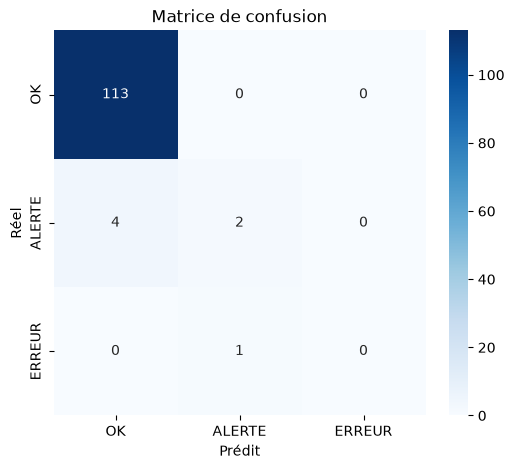

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

**Explication** : `sns.heatmap` affiche la matrice de confusion sous forme de carte de chaleur, où chaque case est colorée selon sa valeur, avec le nombre exact affiché grâce à `annot=True`. Cela rend la lecture plus intuitive qu'un simple tableau de chiffres.

**Résultat** : on voit visuellement une case très foncée en "OK / OK" (113 prédictions correctes), et les erreurs de classification pour "ALERTE" et "ERREUR" ressortent clairement en dehors de la diagonale.

###  5) Afficher et commenter le rapport de classificaton

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, labels=labels, zero_division=0))

              precision    recall  f1-score   support

          OK       0.97      1.00      0.98       113
      ALERTE       0.67      0.33      0.44         6
      ERREUR       0.00      0.00      0.00         1

    accuracy                           0.96       120
   macro avg       0.54      0.44      0.48       120
weighted avg       0.94      0.96      0.95       120



**Explication** : `classification_report` calcule, pour chaque classe, trois indicateurs :
- **Precision** : parmi les mesures prédites dans cette classe, combien le sont réellement (mesure la fiabilité des alertes positives).
- **Recall** : parmi les mesures réellement dans cette classe, combien ont été détectées (mesure la capacité à ne rien rater).
- **F1-score** : moyenne harmonique entre precision et recall, un bon résumé des deux à la fois.

Le paramètre `zero_division=0` indique à sklearn comment se comporter quand un calcul de precision (ou recall) tombe sur une division par zéro — ce qui arrive ici pour la classe "ERREUR", puisque le modèle ne l'a jamais prédite (0 prédiction dans cette classe, donc 0 ÷ 0 pour la precision). Plutôt que d'afficher un avertissement (`UndefinedMetricWarning`), on demande explicitement à sklearn de renvoyer 0.0 dans ce cas, ce qui rend le résultat plus propre à lire.


**Résultat** :
- OK : precision 0.97, recall 1.00, f1-score 0.98 — le modèle gère très bien cette classe majoritaire.
- ALERTE : precision 0.67, recall 0.33, f1-score 0.44 — le modèle rate les deux tiers des vraies alertes.
- ERREUR : precision 0.00, recall 0.00, f1-score 0.00 — le modèle ne détecte aucune erreur.

Cela confirme concrètement pourquoi l'Accuracy globale (95.83 %) était trompeuse : elle masquait une performance très faible sur les classes minoritaires, qui sont pourtant les plus importantes à détecter dans ce contexte (une entreprise veut surtout être alertée des anomalies, pas confirmer que tout va bien).

###  6) Dans quel cas de problème de classification est-il plus indiqué d’évaluer avec la precision ; même question avec recall; même question avec F1 score; même question avec accuracy 

- **Precision** : à utiliser quand une **fausse alerte coûte cher**. Exemple : un email important classé à tort comme spam — mieux vaut ne déclencher une alerte que quand on est vraiment sûr.
- **Recall** : à utiliser quand **rater un cas réel est grave**. Exemple : un test médical pour une maladie sérieuse — mieux vaut avoir quelques fausses alertes que de laisser passer un vrai cas. Ici, rater une vraie panne ("ERREUR") est plus dangereux que de se tromper sur une alerte, donc le recall est souvent la priorité pour ce genre de système de surveillance.
- **F1-score** : à utiliser quand on veut un bon équilibre entre les deux, sans privilégier l'un plus que l'autre — utile notamment pour les classes rares comme "ALERTE" ou "ERREUR", où regarder une seule des deux métriques donnerait une image incomplète.
- **Accuracy** : à utiliser seulement quand les classes sont à peu près équilibrées et que toutes les erreurs se valent — ce qui n'est pas le cas ici, avec 94 % de "OK".

## Partie 8 – Sauvegarde du modèle

**Objectif** : sauvegarder le modèle entraîné sur le disque, afin de pouvoir le réutiliser plus tard sans avoir à refaire tout l'entraînement à chaque fois.

### 1) Sauvegarder le modèle avec Joblib pour avoir models/modele_capteurs.joblib

In [41]:
import joblib

joblib.dump(model, "../models/modele_capteur.joblib")

['../models/modele_capteur.joblib']

**Explication** : `joblib.dump(objet, chemin)` sérialise l'objet Python (ici, le modèle KNN entraîné) et l'enregistre dans un fichier sur le disque. 

Joblib est l'outil recommandé par la documentation de scikit-learn pour sauvegarder des modèles, car il est optimisé pour les objets contenant de gros tableaux numpy (ce qui est le cas des modèles scikit-learn).

**Résultat** : un fichier `modele_capteur.joblib` est créé dans le dossier `models/`.

###  2) Sauvegarder le modèle avec Pickle pour avoir models/modele_capteurs.pkl 

In [42]:
import pickle

with open("../models/modele_capteur.pkl", "wb") as f:
    pickle.dump(model, f)

**Explication** : `pickle` est le module standard de Python pour sérialiser n'importe quel objet Python. `open(..., "wb")` ouvre un fichier en écriture binaire (`wb` = write binary, nécessaire car le format pickle n'est pas du texte lisible), et `pickle.dump(objet, fichier)` y écrit l'objet sérialisé. Le bloc `with open(...) as f:` garantit que le fichier est correctement fermé après l'écriture, même en cas d'erreur.

**Résultat** : un fichier `modele_capteur.pkl` est créé dans le dossier `models/`.

## Partie 9 – Chargement du modèle 

**Objectif** : recharger le modèle sauvegardé depuis le disque (sans avoir besoin de le réentraîner), et l'utiliser pour prédire l'état d'une toute nouvelle mesure.

### 1) Charger le modèle 

In [43]:
model_loaded = joblib.load("../models/modele_capteur.joblib")

print(type(model_loaded))

<class 'sklearn.neighbors._classification.KNeighborsClassifier'>


**Explication** : `joblib.load(chemin)` lit le fichier sauvegardé à la Partie 8 et reconstruit l'objet Python original, ici, le modèle KNN entraîné, avec tous ses paramètres appris (les 476 observations de X_train_scaled qu'il a mémorisées).

**Résultat** : `model_loaded` est bien un objet de type `KNeighborsClassifier`, identique au modèle entraîné initialement.

### 2) Faire une prédiction avec une nouvelle mesure 

In [44]:
nouvelle_mesure = pd.DataFrame([{
    "temperature": 26.5,
    "humidite": 60.0,
    "pression": 1015.0,
    "consommation": 210.0
}])

# On applique les mêmes étapes de prétraitement que sur les données d'entraînement
nouvelle_mesure_imputed = pd.DataFrame(imputer.transform(nouvelle_mesure), columns=nouvelle_mesure.columns)
nouvelle_mesure_scaled = pd.DataFrame(scaler.transform(nouvelle_mesure_imputed), columns=nouvelle_mesure.columns)

prediction = model_loaded.predict(nouvelle_mesure_scaled)
print("Prédiction :", prediction)

Prédiction : ['OK']


**Explication** : on crée une nouvelle mesure fictive sous forme de DataFrame à une seule ligne, avec les mêmes colonnes que X (`temperature`, `humidite`, `pression`, `consommation`). Il est essentiel d'appliquer **exactement les mêmes transformations** que sur les données d'entraînement — imputation (`imputer.transform`) puis standardisation (`scaler.transform`), avant de pouvoir faire une prédiction, sinon le modèle recevrait des données sur une échelle différente de celle qu'il a apprise.

**Résultat** : pour une mesure avec des valeurs dans la plage habituelle (température 26.5°C, humidité 60%, pression 1015, consommation 210), le modèle prédit l'état **"OK"**.